In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '4'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import holidays
import optuna

# Load data from previous notebooks
charging_sessions = pd.read_parquet('intermediate_data/charging_sessions.parquet')
hourly_kwh = pd.read_parquet('intermediate_data/hourly_kwh.parquet')

### 5. Regression

In this section, we build a regression model to predict hourly kWh consumption for Site 1. Weather data is excluded to ensure the model can generate forward-looking predictions, as charging behavior shifted significantly following the weather data's cutoff point. This exclusion allows us to test the model's performance on newer data that reflects these evolving charging patterns.

The steps we took to prepare and train are outlined in the following:

**1. Hourly Aggregation:** We transform session-level data into hourly rows, adding `num_charging_cars` (cars actively charging that hour), `sum_miles_requested`, and `sum_minutes_available` alongside the `kwh_hourly` target from KPI 1.

**2. Data Removal:** Two time periods are excluded because they distort the training set and the validation -- the Corona lockdown period (2020-08-04 to 2020-11-17) and a site shutdown anomaly (2021-07-16 to 2021-07-29).

**3. Feature Engineering:** We add lag features (kWh at 24h, 48h, 72h, 168h), rolling statistics (24h and 168h mean/std), lagged charging activity (cars, miles, minutes at 24h), and temporal features (hour of day, day of week, weekend flag, month, cyclical encodings, holiday indicator, and a post-Corona flag). The data is split chronologically into train, validation, and holdout sets. The valdiation and houldout set being roughly 3 months long. We also add weights which get higher the more recent the data as the behaviour changes with time.

**4. Model Comparison:** Ten common regression algorithms are compared on the validation set (Linear Regression, Ridge, Lasso, ElasticNet, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, KNN, XGBoost) using default values. Random Forest achieved the highest R² score. So we choose Random Forrest for further hyperparameter tuning and our model. 

**5. Hyperparameter Tuning:** We use Optuna, a Bayesian optimization framework which searches the hyperparameter space by learning from previous trials rather than testing randomly. It tunes `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_features` over 50 trials (more trials only slightly improve performance) using TimeSeriesSplit cross-validation. The best configuration is then evaluated on validation and holdout sets to confirm generalization.


In [2]:
# Transform charging sessions into hourly data for regression

# we only use data from site 1
prediction_df_charging_sessions = charging_sessions.copy()
df = prediction_df_charging_sessions[prediction_df_charging_sessions["site_id"]==1]

# Reuses kwh_hourly from KPI 1, calculates additional features: num_charging_cars, sum_miles_requested, sum_minutes_available
rows = []

for _, row in df.iterrows():
    session_start = row['connection_time']
    session_end = row['disconnect_time']
    # Use done_charging_time if available, otherwise fall back to disconnect_time
    charging_end = row['done_charging_time'] if pd.notna(row['done_charging_time']) else row['disconnect_time']
    miles_requested = row['miles_requested']
    minutes_available = row['minutes_available']

    start_hour = session_start.floor('h')
    end_hour = session_end.floor('h')
    all_hours = pd.date_range(start=start_hour, end=end_hour, freq='h')

    for i, hour in enumerate(all_hours):
        hour_start = hour
        hour_end = hour + pd.Timedelta(hours=1)

        # Car is charging if session started before hour ends AND charging ended after hour starts
        is_charging = (session_start < hour_end) and (charging_end > hour_start)

        hours_elapsed = i
        remaining_minutes = np.nan
        if pd.notna(minutes_available):
            remaining_minutes = max(0, minutes_available - (hours_elapsed * 60))

        rows.append({
            'hour': hour,
            'is_charging': 1 if is_charging else 0,
            'miles_requested': miles_requested if pd.notna(miles_requested) else np.nan,
            'minutes_available_remaining': remaining_minutes
        })

# Aggregate additional features by hour
hourly_features = pd.DataFrame(rows).groupby('hour').agg(
    num_charging_cars=('is_charging', 'sum'),
    sum_miles_requested=('miles_requested', lambda x: x.sum(skipna=True)),
    sum_minutes_available=('minutes_available_remaining', lambda x: x.sum(skipna=True))
).reset_index()

# Get kWh data from KPI 1 (filter for site 1)
hourly_kwh_site1 = hourly_kwh[hourly_kwh['site_id'] == 1][['hour', 'kwh_hourly']].copy()
hourly_kwh_site1['hour'] = pd.to_datetime(hourly_kwh_site1['hour']).dt.tz_localize(None)

# Create complete hourly range
min_hour = min(hourly_kwh_site1['hour'].min(), hourly_features['hour'].min())
max_hour = max(hourly_kwh_site1['hour'].max(), hourly_features['hour'].max())
complete_hours = pd.date_range(start=min_hour, end=max_hour, freq='h')

# Build complete dataframe
hourly_regression_df = pd.DataFrame({'hour': complete_hours})
hourly_regression_df = hourly_regression_df.merge(hourly_kwh_site1, on='hour', how='left')
hourly_regression_df = hourly_regression_df.merge(hourly_features, on='hour', how='left')

# Fill NaN with 0 for hours without any sessions
hourly_regression_df = hourly_regression_df.fillna(0)

# Add date and hour columns
hourly_regression_df['date'] = hourly_regression_df['hour'].dt.date
hourly_regression_df['hour_of_day'] = hourly_regression_df['hour'].dt.hour


### Data Removal Audit: From When Till When ###
           Reason       From         To  Days
    Corona Period 2020-08-04 2020-11-17   106
Hardcoded Anomaly 2021-07-16 2021-07-29    14
---------------------------------------------
Total days removed: 120
Rows remaining: 23690


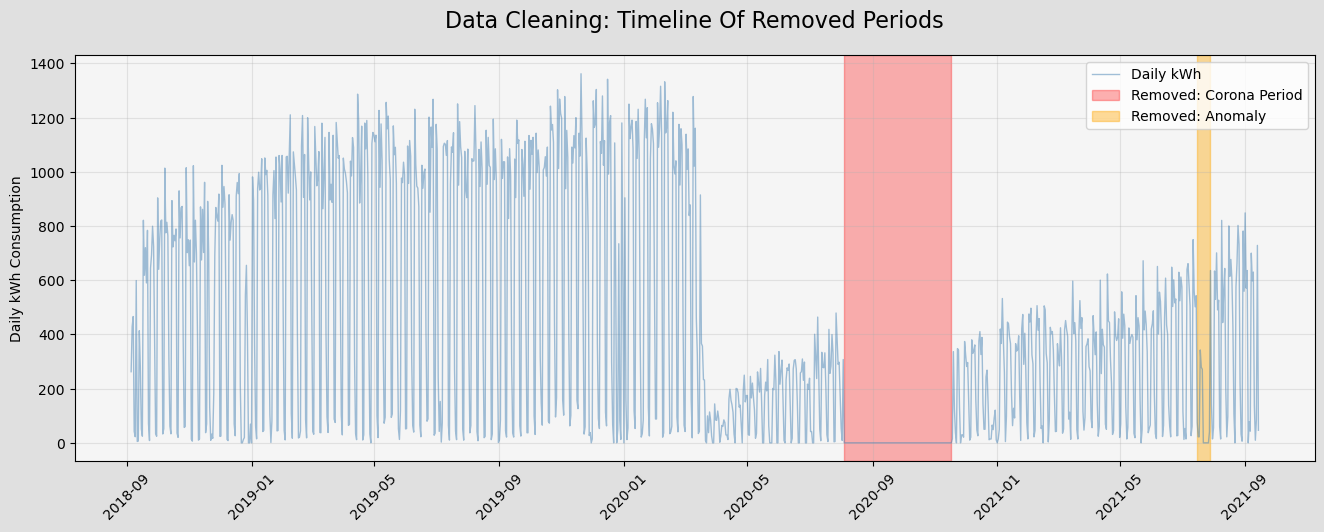

In [3]:
# We remove two parts of the data which are not useful specifically corona and 2021-07-16 to 2021-07-29 as the site seems to be shutdown for large parts of the timespan

# Period 1: Corona
corona_start, corona_end = pd.to_datetime('2020-08-04'), pd.to_datetime('2020-11-17')

# Period 2: Anomaly
anomaly_start, anomaly_end = pd.to_datetime(' 2021-07-16'), pd.to_datetime('2021-07-29')

removal_log = [
    {
        'Reason': 'Corona Period',
        'From': corona_start.date(),
        'To': corona_end.date(),
        'Days': (corona_end - corona_start).days + 1
    },
    {
        'Reason': 'Hardcoded Anomaly',
        'From': anomaly_start.date(),
        'To': anomaly_end.date(),
        'Days': (anomaly_end - anomaly_start).days + 1
    }
]
df_removal_summary = pd.DataFrame(removal_log)


# Remove both periods from the main dataframe
hourly_cleaned_df = hourly_regression_df[
    ~(hourly_regression_df['hour'].between(corona_start, corona_end)) &
    ~(hourly_regression_df['hour'].between(anomaly_start, anomaly_end))
].copy()

#Printed Summary Output
print("### Data Removal Audit: From When Till When ###")
print(df_removal_summary.to_string(index=False))
print("-" * 45)
print(f"Total days removed: {df_removal_summary['Days'].sum()}")
print(f"Rows remaining: {len(hourly_cleaned_df)}")

# Visualization
daily_full = hourly_regression_df.groupby(hourly_regression_df['hour'].dt.date)['kwh_hourly'].sum().reset_index()
daily_full.columns = ['date', 'daily_kwh']
daily_full['date'] = pd.to_datetime(daily_full['date'])

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('#E0E0E0')
ax.set_facecolor('#F5F5F5')

ax.plot(daily_full['date'], daily_full['daily_kwh'], color='steelblue', alpha=0.5, lw=1, label='Daily kWh')

ax.axvspan(corona_start, corona_end, alpha=0.3, color='red', label='Removed: Corona Period')
ax.axvspan(anomaly_start, anomaly_end, alpha=0.4, color='orange', label='Removed: Anomaly')

ax.set_title('Data Cleaning: Timeline Of Removed Periods', fontsize=16, pad=20)
ax.set_ylabel('Daily kWh Consumption')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.subplots_adjust(bottom=0.3)
plt.show()

In [4]:
# Prepare data for regression
regression_features_df = hourly_cleaned_df.copy()

us_holidays = holidays.US(state='CA', years=range(2018, 2022))

# Lag features for kWh
for lag in [24, 48, 72, 168]:
    regression_features_df[f'kwh_lag_{lag}h'] = regression_features_df['kwh_hourly'].shift(lag)

# Lag features for num_charging_cars, miles_requested, minutes_available (24h lag)
regression_features_df['num_cars_lag_24h'] = regression_features_df['num_charging_cars'].shift(24)
regression_features_df['miles_requested_lag_24h'] = regression_features_df['sum_miles_requested'].shift(24)
regression_features_df['minutes_available_lag_24h'] = regression_features_df['sum_minutes_available'].shift(24)

# Rolling statistics for kWh
regression_features_df['kwh_roll_mean_24h'] = regression_features_df['kwh_hourly'].rolling(24).mean().shift(24)
regression_features_df['kwh_roll_std_24h'] = regression_features_df['kwh_hourly'].rolling(24).std().shift(24)
regression_features_df['kwh_roll_mean_168h'] = regression_features_df['kwh_hourly'].rolling(168).mean().shift(24)

# Rolling statistics for num_charging_cars
regression_features_df['num_cars_roll_mean_24h'] = regression_features_df['num_charging_cars'].rolling(24).mean().shift(24)

# Temporal features
regression_features_df['day_of_week'] = regression_features_df['hour'].dt.dayofweek
regression_features_df['is_weekend'] = (regression_features_df['day_of_week'] >= 5).astype(int)
regression_features_df['month'] = regression_features_df['hour'].dt.month
regression_features_df['day_of_month'] = regression_features_df['hour'].dt.day
regression_features_df['week_of_year'] = regression_features_df['hour'].dt.isocalendar().week.astype(int)
regression_features_df['after_corona'] = (regression_features_df['hour'] > pd.to_datetime('2020-03-06')).astype(int)
regression_features_df['is_holiday'] = regression_features_df['hour'].dt.date.apply(lambda x: 1 if x in us_holidays else 0)

# Cyclical encoding
regression_features_df['hour_sin'] = np.sin(2 * np.pi * regression_features_df['hour_of_day'] / 24)
regression_features_df['hour_cos'] = np.cos(2 * np.pi * regression_features_df['hour_of_day'] / 24)
regression_features_df['dow_sin'] = np.sin(2 * np.pi * regression_features_df['day_of_week'] / 7)
regression_features_df['dow_cos'] = np.cos(2 * np.pi * regression_features_df['day_of_week'] / 7)

regression_features_df = regression_features_df.dropna()

features_rf = [
    # kWh lag features
    'kwh_lag_24h', 'kwh_lag_48h', 'kwh_lag_72h', 'kwh_lag_168h',
    'kwh_roll_mean_24h', 'kwh_roll_std_24h', 'kwh_roll_mean_168h',
    # lag features for charging activity
    'num_cars_lag_24h', 'miles_requested_lag_24h', 'minutes_available_lag_24h',
    'num_cars_roll_mean_24h',
    # Temporal features
    'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'day_of_month', 'week_of_year',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'after_corona', 'is_holiday'
]

X_rf = regression_features_df[features_rf]
y_rf = regression_features_df['kwh_hourly']

# Sample weights - more recent data gets higher weight
time_numeric = regression_features_df['hour'].astype('int64')
min_weight, max_weight = 1, 6
weights = (time_numeric - time_numeric.min()) / (time_numeric.max() - time_numeric.min())
weights = weights * (max_weight - min_weight) + min_weight

# Train / Validation / Holdout split
# about 3 months
holdout_size = 720 * 3
val_size = 720 * 3

X_train = X_rf.iloc[:-(holdout_size + val_size)]
y_train = y_rf.iloc[:-(holdout_size + val_size)]
weights_train = weights.iloc[:-(holdout_size + val_size)]

X_val = X_rf.iloc[-(holdout_size + val_size):-holdout_size]
y_val = y_rf.iloc[-(holdout_size + val_size):-holdout_size]

In [5]:
# Reusable function for calculating regression metrics
def calc_regression_metrics(y_true, y_pred, set_name=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mask = y_true > 0.1
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'Set': set_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE (%)': mape}

Training samples: 19179, Validation samples: 2160

COMPARING ALL REGRESSION MODELS

Training Linear Regression...
  RMSE: 9.346, MAE: 6.993, R²: 0.710, MAPE: 152.8%

Training Ridge...
  RMSE: 9.345, MAE: 6.992, R²: 0.710, MAPE: 152.8%

Training Lasso...
  RMSE: 8.795, MAE: 6.249, R²: 0.743, MAPE: 151.8%

Training ElasticNet...
  RMSE: 9.269, MAE: 7.013, R²: 0.714, MAPE: 162.3%

Training Decision Tree...
  RMSE: 10.639, MAE: 6.144, R²: 0.624, MAPE: 123.6%

Training Random Forest...
  RMSE: 7.915, MAE: 4.731, R²: 0.792, MAPE: 86.1%

Training Gradient Boosting...
  RMSE: 7.962, MAE: 4.884, R²: 0.789, MAPE: 95.4%

Training AdaBoost...
  RMSE: 9.873, MAE: 7.151, R²: 0.676, MAPE: 182.4%

Training KNN...
  RMSE: 9.642, MAE: 5.303, R²: 0.691, MAPE: 78.3%

Training XGBoost...
  RMSE: 9.149, MAE: 5.230, R²: 0.722, MAPE: 80.9%

RESULTS RANKED BY R² (Best to Worst)
     RMSE      MAE       R²   MAPE (%)             Model
 7.915435 4.731041 0.791763  86.101863     Random Forest
 7.961577 4.884319 0

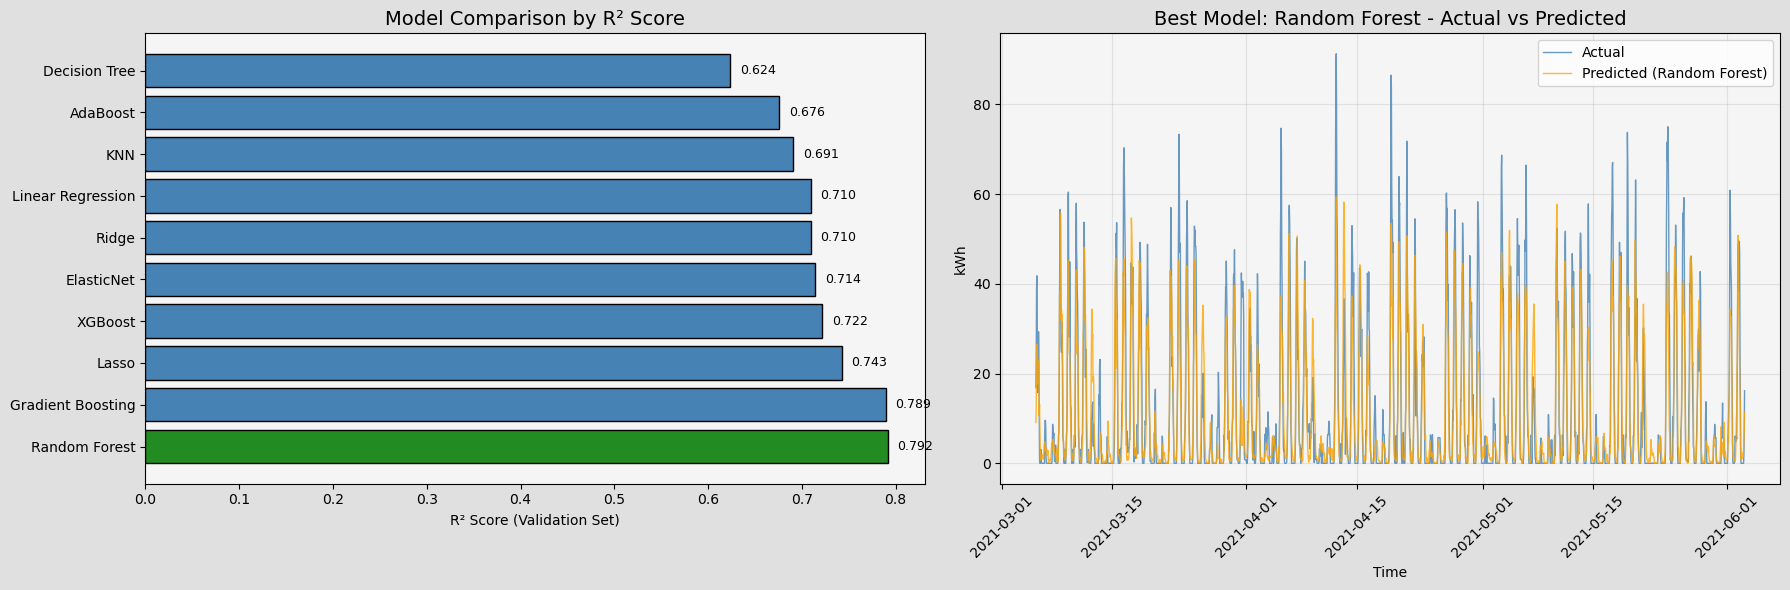

In [6]:
# We Compare All Standard Models to Find the best algorithm for our use case
# in the end we choose the Random Forest regressor because it performed best

# Uses X_train, y_train, X_val, y_val from previous cell

# Scale features for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")
print("\n" + "="*80)
print("COMPARING ALL REGRESSION MODELS")
print("="*80)

# Define all models to compare
models = {
    'Linear Regression': LinearRegression(), 
    'Ridge': Ridge(),                          
    'Lasso': Lasso(),                          
    'ElasticNet': ElasticNet(),               
    'Decision Tree': DecisionTreeRegressor(random_state=10),
    'Random Forest': RandomForestRegressor(random_state=10, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=10),
    'AdaBoost': AdaBoostRegressor(random_state=10),
    'KNN': KNeighborsRegressor(),              
    'XGBoost': XGBRegressor(random_state=10, n_jobs=-1)
}


# Store results
results = []

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for linear models and KNN/SVR
    if name in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'KNN']:
        X_tr, X_te = X_train_scaled, X_val_scaled
    else:
        X_tr, X_te = X_train, X_val

    # Fit with sample weights if supported
    try:
        if name in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'KNN', 'AdaBoost']:
            model.fit(X_tr, y_train)
        else:
            model.fit(X_tr, y_train, sample_weight=weights_train)
    except:
        model.fit(X_tr, y_train)

    # Predict on validation set
    pred_val = model.predict(X_te)

    # Calculate metrics using shared function
    metrics = calc_regression_metrics(y_val, pred_val, name)
    metrics['Model'] = metrics.pop('Set')
    results.append(metrics)

    print(f"  RMSE: {metrics['RMSE']:.3f}, MAE: {metrics['MAE']:.3f}, R²: {metrics['R²']:.3f}, MAPE: {metrics['MAPE (%)']:.1f}%")

# Create results dataframe and sort by R²
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)

print("\n" + "="*80)
print("RESULTS RANKED BY R² (Best to Worst)")
print("="*80)
print(results_df.to_string(index=False))

# Get best model
best_model_name = results_df.iloc[0]['Model']
print(f"\nBEST MODEL: {best_model_name} with R² = {results_df.iloc[0]['R²']:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#E0E0E0')

# Bar chart comparing models
axes[0].set_facecolor('#F5F5F5')
colors = ['forestgreen' if m == best_model_name else 'steelblue' for m in results_df['Model']]
bars = axes[0].barh(results_df['Model'], results_df['R²'], color=colors, edgecolor='black')
axes[0].set_xlabel('R² Score (Validation Set)')
axes[0].set_title('Model Comparison by R² Score', fontsize=14)
axes[0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
for i, (idx, row) in enumerate(results_df.iterrows()):
    axes[0].text(row['R²'] + 0.01, i, f"{row['R²']:.3f}", va='center', fontsize=9)

# Predicted vs Actual for best model (retrain best model for plotting)
best_model = models[best_model_name]
if best_model_name in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'KNN']:
    pred_best = best_model.predict(X_val_scaled)
else:
    pred_best = best_model.predict(X_val)

val_hours = regression_features_df['hour'].iloc[-(holdout_size + val_size):-holdout_size]
axes[1].set_facecolor('#F5F5F5')
axes[1].plot(val_hours, y_val.values, label='Actual', color='steelblue', linewidth=1, alpha=0.8)
axes[1].plot(val_hours, pred_best, label=f'Predicted ({best_model_name})', color='orange', linewidth=1, alpha=0.8)
axes[1].set_title(f'Best Model: {best_model_name} - Actual vs Predicted', fontsize=14)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('kWh')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Best RandomForestRegressor params:
  n_estimators: 800
  max_depth: 20
  min_samples_split: 4
  min_samples_leaf: 5
  max_features: 0.5
  bootstrap: True

TRAIN      - RMSE=5.985, MAE=3.119, R²=0.973, MAPE=59.0%
VALIDATION - RMSE=7.729, MAE=4.649, R²=0.801, MAPE=85.4%


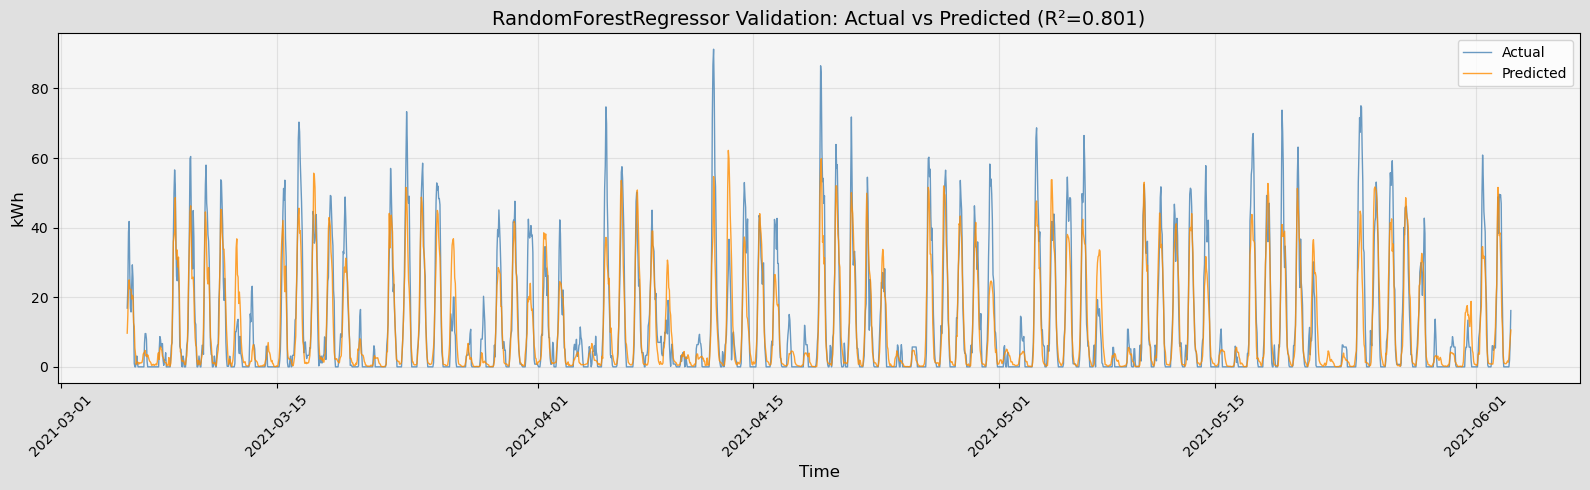

In [7]:
# --- Random Forest Regressor: Hyperparameter Tuning with Optuna ---
optuna.logging.set_verbosity(optuna.logging.CRITICAL)

X_train_rf = X_train.copy()
y_train_rf = y_train.copy()
X_val_rf = X_val.copy()
y_val_rf = y_val.copy()
weights_train_rf = weights_train.copy()

def rf_objective(trial):
    # define search space for otpuna
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),        
        'max_depth': trial.suggest_int('max_depth', 3, 30),                             
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),            
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),              
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None, 0.5, 0.75]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),            
    }
    # timeseriessplit to prevent leakage in training
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    # Perform time-series cross-validation to evaluate model R² performance using weighted training data.
    for train_idx, val_idx in tscv.split(X_train_rf):
        X_tr, X_te = X_train_rf.iloc[train_idx], X_train_rf.iloc[val_idx]
        y_tr, y_te = y_train_rf.iloc[train_idx], y_train_rf.iloc[val_idx]
        w_tr = weights_train_rf.iloc[train_idx]

        model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
        model.fit(X_tr, y_tr, sample_weight=w_tr)
        pred = model.predict(X_te)
        scores.append(r2_score(y_te, pred))

    return np.mean(scores)

#set seed for the optuna sampler
sampler = optuna.samplers.TPESampler(seed=42)

# call rf_objective 50 times using optuna Hyperparameters
rf_study = optuna.create_study(direction='maximize', study_name='random_forest',sampler=sampler)
rf_study.optimize(rf_objective, n_trials=50)

# Retrain with best params on full training set
best_rf = RandomForestRegressor(**rf_study.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train_rf, y_train_rf, sample_weight=weights_train_rf)

# Generate predictions for both training and validation sets
pred_train_rf = best_rf.predict(X_train_rf)
pred_val_rf = best_rf.predict(X_val_rf)

# Calculate metrics using shared function
train_metrics_rf = calc_regression_metrics(y_train_rf, pred_train_rf, 'Train')
val_metrics_rf = calc_regression_metrics(y_val_rf, pred_val_rf, 'Validation')

# Print metrics
print("Best RandomForestRegressor params:")
for param, value in rf_study.best_params.items():
    print(f"  {param}: {value}")

print(f"\nTRAIN      - RMSE={train_metrics_rf['RMSE']:.3f}, MAE={train_metrics_rf['MAE']:.3f}, R²={train_metrics_rf['R²']:.3f}, MAPE={train_metrics_rf['MAPE (%)']:.1f}%")
print(f"VALIDATION - RMSE={val_metrics_rf['RMSE']:.3f}, MAE={val_metrics_rf['MAE']:.3f}, R²={val_metrics_rf['R²']:.3f}, MAPE={val_metrics_rf['MAPE (%)']:.1f}%")

# Visualization: Validation Actual vs Predicted
fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#E0E0E0')
ax.set_facecolor('#F5F5F5')

val_hours_rf = regression_features_df['hour'].iloc[-(holdout_size + val_size):-holdout_size]
ax.plot(val_hours_rf, y_val_rf.values, label='Actual', color='steelblue', linewidth=1, alpha=0.8)
ax.plot(val_hours_rf, pred_val_rf, label='Predicted', color='darkorange', linewidth=1, alpha=0.8)
ax.set_title(f'RandomForestRegressor Validation: Actual vs Predicted (R²={val_metrics_rf["R²"]:.3f})', fontsize=14)
ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('kWh', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

RANDOM FOREST: VALIDATION vs HOLDOUT
VALIDATION - RMSE=7.729, MAE=4.649, R²=0.801, MAPE=85.4%
HOLDOUT    - RMSE=11.616, MAE=6.445, R²=0.783, MAPE=104.7%


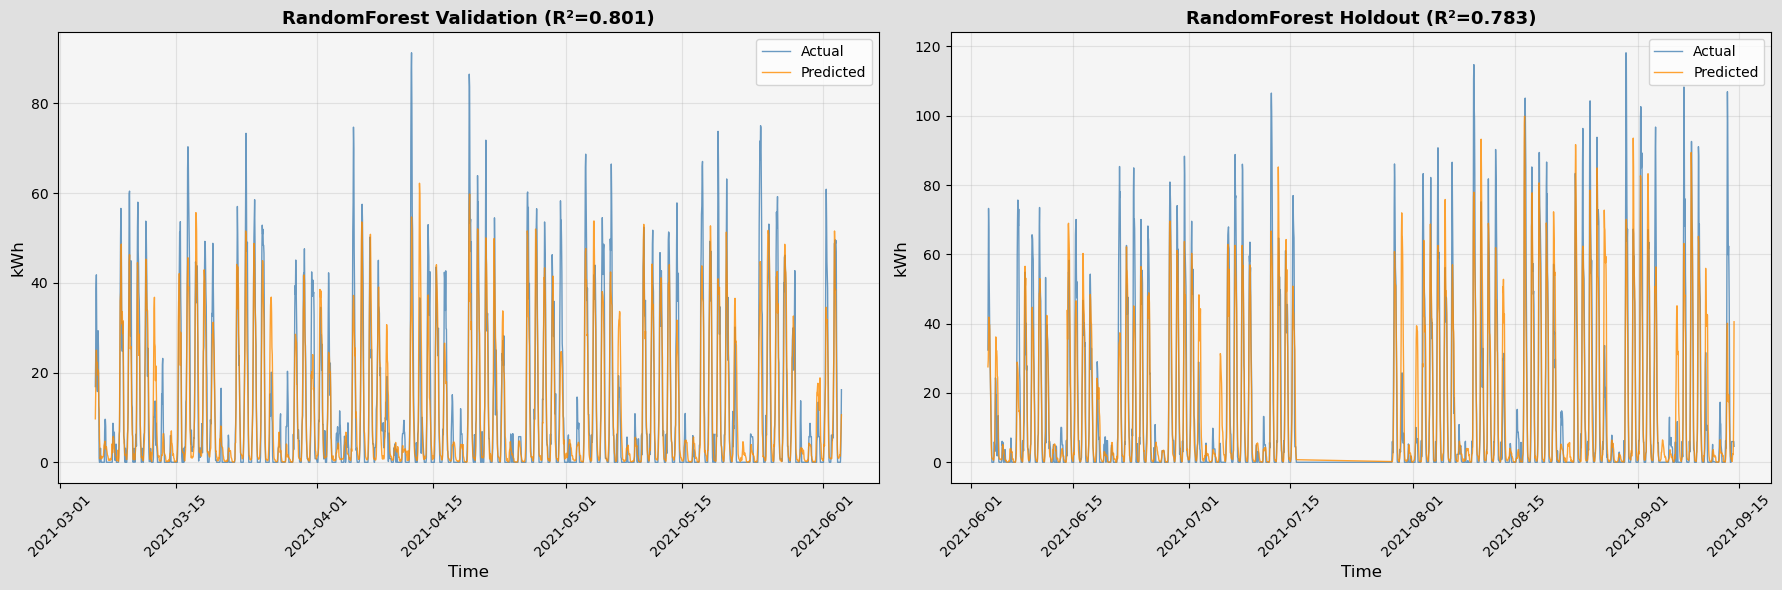

In [8]:
# --- RandomForestRegressor: Validation vs Holdout Set Comparison ---

# Get holdout data
X_holdout_rf = X_rf.iloc[-holdout_size:]
y_holdout_rf = y_rf.iloc[-holdout_size:]

# Predictions on both sets
pred_val_rf = best_rf.predict(X_val_rf)
pred_holdout_rf = best_rf.predict(X_holdout_rf)

# Calculate metrics using shared function
val_metrics_rf = calc_regression_metrics(y_val_rf, pred_val_rf, 'Validation')
holdout_metrics_rf = calc_regression_metrics(y_holdout_rf, pred_holdout_rf, 'Holdout')

# Display comparison
print("="*70)
print("RANDOM FOREST: VALIDATION vs HOLDOUT")
print("="*70)
print(f"VALIDATION - RMSE={val_metrics_rf['RMSE']:.3f}, MAE={val_metrics_rf['MAE']:.3f}, R²={val_metrics_rf['R²']:.3f}, MAPE={val_metrics_rf['MAPE (%)']:.1f}%")
print(f"HOLDOUT    - RMSE={holdout_metrics_rf['RMSE']:.3f}, MAE={holdout_metrics_rf['MAE']:.3f}, R²={holdout_metrics_rf['R²']:.3f}, MAPE={holdout_metrics_rf['MAPE (%)']:.1f}%")
print("="*70)

# Visualization - 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor('#E0E0E0')

# 1. Validation: Actual vs Predicted
val_hours_rf = regression_features_df['hour'].iloc[-(holdout_size + val_size):-holdout_size]
axes[0].set_facecolor('#F5F5F5')
axes[0].plot(val_hours_rf, y_val_rf.values, label='Actual', color='steelblue', linewidth=1, alpha=0.8)
axes[0].plot(val_hours_rf, pred_val_rf, label='Predicted', color='darkorange', linewidth=1, alpha=0.8)
axes[0].set_title(f'RandomForest Validation (R²={val_metrics_rf["R²"]:.3f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time', fontsize=12)
axes[0].set_ylabel('kWh', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# 2. Holdout: Actual vs Predicted
holdout_hours_rf = regression_features_df['hour'].iloc[-holdout_size:]
axes[1].set_facecolor('#F5F5F5')
axes[1].plot(holdout_hours_rf, y_holdout_rf.values, label='Actual', color='steelblue', linewidth=1, alpha=0.8)
axes[1].plot(holdout_hours_rf, pred_holdout_rf, label='Predicted', color='darkorange', linewidth=1, alpha=0.8)
axes[1].set_title(f'RandomForest Holdout (R²={holdout_metrics_rf["R²"]:.3f})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time', fontsize=12)
axes[1].set_ylabel('kWh', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()